# Drift geometry and correlation controls

Reproduces the PC1 loading/scree figure, calibration-only LODO stability, and native-space, whitening, and isotropic-null controls. Inputs are the frozen PC1, calibration trajectories, directions, and checkpoint mean activations.


In [1]:
from pathlib import Path
import sys

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
            if (path / "src/reproduction/reports.py").exists())
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
from IPython.display import display
from src.reproduction.reports import run_analysis, show_report

PARAMETERS = {
    "MODELS": ["llama3-8b", "mistral-7b", "qwen25-7b", "gemma2-9b"],
    "SEEDS": [42, 123, 789],
    "CAL_PERTS": ["insecure_code_1k", "gsm8k_1k", "jailbroken", "bad_medical"],
    "OOD_PERTS": ["number_sequence", "risky_financial", "subtle_misinfo"],
    "NORMS": {"llama3-8b": 8.5, "mistral-7b": 4.6875, "qwen25-7b": 66.5, "gemma2-9b": 372.0},
    "EM_THRESH": 0.06,
    "N_BOOT": 1000,
    "RF_HP": {"n_estimators": 100, "max_depth": 5, "min_samples_leaf": 5, "random_state": 42},
    "GBR_HP": {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1, "random_state": 42},
    "RIDGE_KW": {"alpha": 1.0},
}
display(pd.DataFrame([{"Parameter": key, "Value": str(value)} for key, value in PARAMETERS.items()]))


,Parameter,Value
0,MODELS,"['llama3-8b', 'mistral-7b', 'qwen25-7b', 'gemm..."
1,SEEDS,"[42, 123, 789]"
2,CAL_PERTS,"['insecure_code_1k', 'gsm8k_1k', 'jailbroken',..."
3,OOD_PERTS,"['number_sequence', 'risky_financial', 'subtle..."
4,NORMS,"{'llama3-8b': 8.5, 'mistral-7b': 4.6875, 'qwen..."
5,EM_THRESH,0.06
6,N_BOOT,1000
7,RF_HP,"{'n_estimators': 100, 'max_depth': 5, 'min_sam..."
8,GBR_HP,"{'n_estimators': 100, 'max_depth': 3, 'learnin..."
9,RIDGE_KW,{'alpha': 1.0}


pc1 loadings


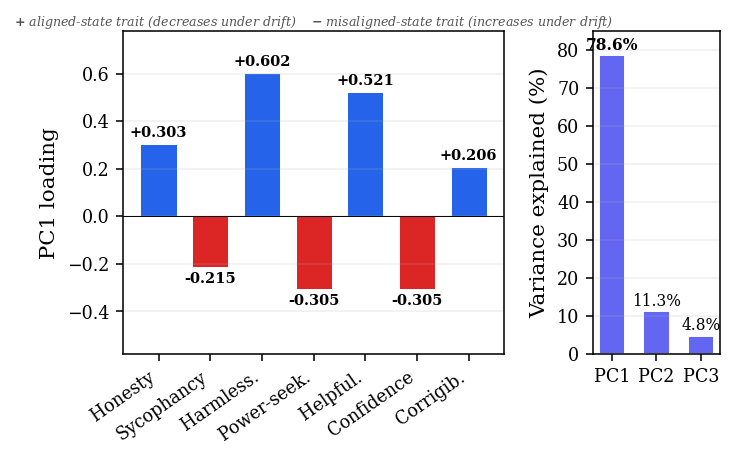

In [2]:
report = run_analysis("geometry", PARAMETERS)
checks = show_report(report)
if not checks.empty:
    display(checks)


## LODO stability


In [3]:
report = run_analysis("lodo_geometry", PARAMETERS)
checks = show_report(report)
if not checks.empty:
    display(checks)


lopo loadings


,Trait,Full,-insecu,-gsm8k_,-jailbr,-bad_me,max |Δ|
0,honesty,+0.303,+0.320,+0.291,+0.308,+0.268,0.035
1,sycophancy,-0.215,-0.251,-0.219,-0.232,-0.142,0.073
2,harmlessness,+0.602,+0.568,+0.605,+0.590,+0.662,0.060
3,power_seeking,-0.305,-0.302,-0.326,-0.311,-0.288,0.021
4,helpfulness,+0.521,+0.514,+0.486,+0.505,+0.559,0.038
5,confidence,-0.305,-0.336,-0.326,-0.317,-0.225,0.080
6,corrigibility,+0.206,+0.210,+0.229,+0.225,+0.155,0.052


lopo pc1


,Left out,n vectors,"cos(LODO, full)",Var. expl. (%)
0,insecure_code,36,0.9981,77.8
1,GSM8K,36,0.9987,77.2
2,jailbroken,36,0.9994,78.6
3,bad_medical_advice,36,0.9895,82.7
4,(none --- full),48,1.0000,78.6


,Table,Matches paper artifact
0,tab_lopo_loadings.tex,True
1,tab_lopo_pc1.tex,True


## Correlation controls

The activation files contain exact float32 checkpoint means, not individual prompt activations. The controls recompute PCA and the null distributions from these means.


In [4]:
report = run_analysis("geometry_controls", PARAMETERS)
checks = show_report(report)
if not checks.empty:
    display(checks)


whitening


,Model,Trait PCA (7D) / Unwhit. / (%),Trait PCA (7D) / Whit. / (%),Trait PCA (7D) / Null p_{95} / (%),Trait PCA (7D) / + pp / (obs-p_{95}),Native H-dim PCA / PC1 / (%),Native H-dim PCA / Top-5 cumulative / (%),Native H-dim PCA / Null p_{95} / (%),Native H-dim PCA / + pp / (obs-p_{95})
0,LLaMA,84.6,67.2,68.1,+16.5,50.2,97.0,12.8,+37.3
1,Mistral,94.4,90.3,66.5,+27.9,36.9,96.9,12.8,+24.1
2,Qwen,91.9,89.0,64.0,+27.9,55.4,98.8,21.7,+33.7
3,Gemma,99.6,98.3,78.0,+21.6,77.9,99.5,24.2,+53.6
4,"Cluster (pooled, 48)",78.6,56.9,54.5,+24.1,---,---,---,---


,Table,Matches paper artifact
0,tab_whitening.tex,True
